In [1]:
# Autonomous Forest Navigation
# Notebook 03: LiDAR Processing

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

SESSION_NAME = "green_2025-06-26-11-20"

LOCAL_SESSION_DIR = (
    DATA_DIR
    / "fomo"
    / "2025-06-26"
    / SESSION_NAME
)

print("LIDAR PROCESSING PROJECT SETUP")
print("=" * 65)

print("Python       :", sys.executable)
print("Working dir  :", CURRENT_DIR)
print("Project root :", PROJECT_ROOT)
print("Session      :", SESSION_NAME)

print("\nExisting local session:")
print(LOCAL_SESSION_DIR)

print(
    "\nSession directory exists:",
    LOCAL_SESSION_DIR.exists()
)

LIDAR PROCESSING PROJECT SETUP
Python       : D:\Autonomous_Forest_Navigation\forest_env\python.exe
Working dir  : D:\Autonomous_Forest_Navigation\notebooks
Project root : D:\Autonomous_Forest_Navigation
Session      : green_2025-06-26-11-20

Existing local session:
D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20

Session directory exists: True


In [2]:
# Inspect the two FoMo LiDAR streams on S3.
# This cell only lists object metadata — it does NOT download LiDAR scans.

import boto3
from botocore import UNSIGNED
from botocore.config import Config
from collections import Counter
from pathlib import PurePosixPath

# ---------------------------------------------------------
# 1. Connect to the public FoMo bucket
# ---------------------------------------------------------

BUCKET = "fomo-dataset"

S3_SESSION_PREFIX = (
    "data/2025-06-26/"
    "green_2025-06-26-11-20/"
)

s3 = boto3.client(
    "s3",
    config=Config(signature_version=UNSIGNED)
)

# ---------------------------------------------------------
# 2. LiDAR folders to inspect
# ---------------------------------------------------------

lidar_prefixes = {
    "Leishen": S3_SESSION_PREFIX + "leishen/",
    "RoboSense": S3_SESSION_PREFIX + "robosense/"
}

lidar_summary = {}

# ---------------------------------------------------------
# 3. Inspect every object under each LiDAR folder
# ---------------------------------------------------------

paginator = s3.get_paginator("list_objects_v2")

for lidar_name, prefix in lidar_prefixes.items():

    objects = []

    for page in paginator.paginate(
        Bucket=BUCKET,
        Prefix=prefix
    ):
        for obj in page.get("Contents", []):

            key = obj["Key"]

            if key.endswith("/"):
                continue

            objects.append(obj)

    # File-extension statistics
    extensions = Counter()

    for obj in objects:

        suffix = PurePosixPath(
            obj["Key"]
        ).suffix.lower()

        if suffix == "":
            suffix = "<no extension>"

        extensions[suffix] += 1

    total_bytes = sum(
        obj["Size"]
        for obj in objects
    )

    lidar_summary[lidar_name] = {
        "objects": objects,
        "total_bytes": total_bytes,
        "extensions": extensions
    }


# ---------------------------------------------------------
# 4. Print summary
# ---------------------------------------------------------

print("FOMO LIDAR STREAM SUMMARY")
print("=" * 75)

for lidar_name, info in lidar_summary.items():

    objects = info["objects"]
    total_gb = (
        info["total_bytes"]
        / (1024 ** 3)
    )

    print(f"\n{lidar_name.upper()}")
    print("-" * 75)

    print(
        f"Number of files : "
        f"{len(objects):,}"
    )

    print(
        f"Total size      : "
        f"{total_gb:.3f} GB"
    )

    print("\nFile types:")

    for extension, count in (
        info["extensions"]
        .most_common()
    ):
        print(
            f"  {extension:15s} "
            f"{count:,}"
        )

    print("\nFirst 10 files:")

    for obj in objects[:10]:

        relative_name = (
            obj["Key"]
            .replace(
                lidar_prefixes[lidar_name],
                ""
            )
        )

        size_mb = (
            obj["Size"]
            / (1024 ** 2)
        )

        print(
            f"  {relative_name:55s} "
            f"{size_mb:8.3f} MB"
        )

FOMO LIDAR STREAM SUMMARY

LEISHEN
---------------------------------------------------------------------------
Number of files : 7,442
Total size      : 21.206 GB

File types:
  .bin            7,442

First 10 files:
  1750951238975969.bin                                       3.325 MB
  1750951239081152.bin                                       3.323 MB
  1750951239178223.bin                                       3.325 MB
  1750951239284681.bin                                       3.319 MB
  1750951239382503.bin                                       3.322 MB
  1750951239480288.bin                                       3.326 MB
  1750951239586167.bin                                       3.326 MB
  1750951239683989.bin                                       3.321 MB
  1750951239781463.bin                                       3.326 MB
  1750951239887109.bin                                       3.325 MB

ROBOSENSE
------------------------------------------------------------------------

In [3]:
# Download and inspect ONE representative RoboSense LiDAR scan.
# We deliberately use a scan near the middle of the trajectory.

# ---------------------------------------------------------
# 1. Sort RoboSense scans by timestamp / filename
# ---------------------------------------------------------

robosense_objects = sorted(
    lidar_summary["RoboSense"]["objects"],
    key=lambda obj: obj["Key"]
)

num_scans = len(robosense_objects)

middle_index = num_scans // 2

selected_scan = robosense_objects[
    middle_index
]

selected_key = selected_scan["Key"]

selected_filename = Path(
    selected_key
).name

scan_size_mb = (
    selected_scan["Size"]
    / (1024 ** 2)
)

print("SELECTED ROBOSENSE SCAN")
print("=" * 70)

print(f"Scan index : {middle_index:,} / {num_scans:,}")
print(f"Filename   : {selected_filename}")
print(f"Size       : {scan_size_mb:.3f} MB")


# ---------------------------------------------------------
# 2. Create a local LiDAR sample folder
# ---------------------------------------------------------

LIDAR_SAMPLE_DIR = (
    LOCAL_SESSION_DIR
    / "robosense_sample"
)

LIDAR_SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOCAL_SCAN_FILE = (
    LIDAR_SAMPLE_DIR
    / selected_filename
)


# ---------------------------------------------------------
# 3. Download only this single scan
# ---------------------------------------------------------

if not LOCAL_SCAN_FILE.exists():

    s3.download_file(
        BUCKET,
        selected_key,
        str(LOCAL_SCAN_FILE)
    )

    print("\nScan downloaded.")

else:

    print("\nScan already exists locally.")


print("Saved to:")
print(LOCAL_SCAN_FILE)


# ---------------------------------------------------------
# 4. Load FoMo LiDAR binary format
#
# Each point:
# [x, y, z, intensity, ring_id, timestamp]
# all stored as float32
# ---------------------------------------------------------

raw = np.fromfile(
    LOCAL_SCAN_FILE,
    dtype=np.float32
)

print("\nRAW BINARY")
print("=" * 70)

print(f"Float32 values : {raw.size:,}")
print(f"Divisible by 6 : {raw.size % 6 == 0}")

if raw.size % 6 != 0:

    raise ValueError(
        "Unexpected LiDAR binary size."
    )

points = raw.reshape(
    -1,
    6
)


# ---------------------------------------------------------
# 5. Basic point-cloud information
# ---------------------------------------------------------

print("\nPOINT CLOUD")
print("=" * 70)

print(
    f"Number of points : "
    f"{len(points):,}"
)

print(
    "Shape            :",
    points.shape
)

print("\nFields:")
print(
    "[x, y, z, intensity, ring_id, timestamp]"
)


# ---------------------------------------------------------
# 6. Coordinate ranges
# ---------------------------------------------------------

labels = [
    "X [m]",
    "Y [m]",
    "Z [m]",
    "Intensity",
    "Ring ID",
    "Point time"
]

print("\nVALUE RANGES")
print("=" * 70)

for i, label in enumerate(labels):

    values = points[:, i]

    print(
        f"{label:12s}: "
        f"{values.min():12.4f} -> "
        f"{values.max():12.4f}"
    )


# ---------------------------------------------------------
# 7. First five points
# ---------------------------------------------------------

print("\nFIRST 5 POINTS")
print("=" * 70)

sample_df = pd.DataFrame(
    points[:5],
    columns=[
        "x",
        "y",
        "z",
        "intensity",
        "ring_id",
        "timestamp"
    ]
)

display(sample_df)

SELECTED ROBOSENSE SCAN
Scan index : 3,751 / 7,503
Filename   : 1750951614000699.bin
Size       : 4.020 MB

Scan downloaded.
Saved to:
D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20\robosense_sample\1750951614000699.bin

RAW BINARY
Float32 values : 1,053,702
Divisible by 6 : True

POINT CLOUD
Number of points : 175,617
Shape            : (175617, 6)

Fields:
[x, y, z, intensity, ring_id, timestamp]

VALUE RANGES
X [m]       :          nan ->          nan
Y [m]       :          nan ->          nan
Z [m]       :          nan ->          nan
Intensity   :          nan ->          nan
Ring ID     :          nan ->          nan
Point time  :          nan ->          nan

FIRST 5 POINTS


,x,y,z,intensity,ring_id,timestamp
0,5.535161e-01,-6.568144e-02,-1.099665e-01,1.000000e+00,-4.251889e-11,5.988867e-05
1,-1.311685e+26,-3.575545e+15,-1.895327e-04,6.818718e-41,2.064505e-40,1.809390e-09
2,5.712744e-40,5.281904e-01,3.642835e-02,-1.209235e-01,1.000000e+00,-4.297364e-11
3,5.988867e-05,-2.762413e-36,2.145088e-19,-1.089226e-18,6.806107e-41,1.125876e-39
4,1.809390e-09,5.712744e-40,7.793391e-01,-7.395283e-03,-8.271842e-02,6.500000e+01


In [4]:
# Download and inspect the selected RoboSense scan

# ---------------------------------------------------------
# Create local sample directory
# ---------------------------------------------------------

LIDAR_SAMPLE_DIR = (
    LOCAL_SESSION_DIR
    / "robosense_sample"
)

LIDAR_SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOCAL_SCAN_FILE = (
    LIDAR_SAMPLE_DIR
    / selected_filename
)

# ---------------------------------------------------------
# Download only this one scan
# ---------------------------------------------------------

if not LOCAL_SCAN_FILE.exists():

    print("Downloading selected LiDAR scan...")

    s3.download_file(
        BUCKET,
        selected_key,
        str(LOCAL_SCAN_FILE)
    )

    print("Scan downloaded successfully.")

else:

    print("Scan already exists locally.")

print("\nSaved to:")
print(LOCAL_SCAN_FILE)

# ---------------------------------------------------------
# Load binary LiDAR data
# Format:
# [x, y, z, intensity, ring_id, timestamp]
# ---------------------------------------------------------

raw = np.fromfile(
    LOCAL_SCAN_FILE,
    dtype=np.float32
)

print("\nRAW BINARY")
print("=" * 70)

print(f"Float32 values : {raw.size:,}")
print(f"Divisible by 6 : {raw.size % 6 == 0}")

if raw.size % 6 != 0:
    raise ValueError(
        "Unexpected RoboSense binary format."
    )

points = raw.reshape(-1, 6)

# ---------------------------------------------------------
# Basic point-cloud information
# ---------------------------------------------------------

print("\nPOINT CLOUD")
print("=" * 70)

print(f"Number of points : {len(points):,}")
print(f"Shape            : {points.shape}")

print(
    "\nFields: "
    "[x, y, z, intensity, ring_id, timestamp]"
)

# ---------------------------------------------------------
# Value ranges
# ---------------------------------------------------------

labels = [
    "X [m]",
    "Y [m]",
    "Z [m]",
    "Intensity",
    "Ring ID",
    "Point time"
]

print("\nVALUE RANGES")
print("=" * 70)

for i, label in enumerate(labels):

    values = points[:, i]

    print(
        f"{label:12s}: "
        f"{values.min():12.4f} -> "
        f"{values.max():12.4f}"
    )

# ---------------------------------------------------------
# First five points
# ---------------------------------------------------------

print("\nFIRST 5 POINTS")
print("=" * 70)

sample_df = pd.DataFrame(
    points[:5],
    columns=[
        "x",
        "y",
        "z",
        "intensity",
        "ring_id",
        "timestamp"
    ]
)

display(sample_df)

Scan already exists locally.

Saved to:
D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20\robosense_sample\1750951614000699.bin

RAW BINARY
Float32 values : 1,053,702
Divisible by 6 : True

POINT CLOUD
Number of points : 175,617
Shape            : (175617, 6)

Fields: [x, y, z, intensity, ring_id, timestamp]

VALUE RANGES
X [m]       :          nan ->          nan
Y [m]       :          nan ->          nan
Z [m]       :          nan ->          nan
Intensity   :          nan ->          nan
Ring ID     :          nan ->          nan
Point time  :          nan ->          nan

FIRST 5 POINTS


,x,y,z,intensity,ring_id,timestamp
0,5.535161e-01,-6.568144e-02,-1.099665e-01,1.000000e+00,-4.251889e-11,5.988867e-05
1,-1.311685e+26,-3.575545e+15,-1.895327e-04,6.818718e-41,2.064505e-40,1.809390e-09
2,5.712744e-40,5.281904e-01,3.642835e-02,-1.209235e-01,1.000000e+00,-4.297364e-11
3,5.988867e-05,-2.762413e-36,2.145088e-19,-1.089226e-18,6.806107e-41,1.125876e-39
4,1.809390e-09,5.712744e-40,7.793391e-01,-7.395283e-03,-8.271842e-02,6.500000e+01


In [5]:
# Correctly decode the RoboSense PointCloud2 binary layout

# ---------------------------------------------------------
# 1. Define the mixed-data-type point structure
# ---------------------------------------------------------

ROBOSENSE_DTYPE = np.dtype([
    ("x",         "<f4"),
    ("y",         "<f4"),
    ("z",         "<f4"),
    ("intensity", "<f4"),
    ("ring_id",   "<u2"),
    ("timestamp", "<f8")
])

file_size_bytes = LOCAL_SCAN_FILE.stat().st_size

print("ROBOSENSE BINARY FORMAT CHECK")
print("=" * 70)

print(f"File size          : {file_size_bytes:,} bytes")
print(f"Bytes per point    : {ROBOSENSE_DTYPE.itemsize}")
print(
    f"Exactly divisible : "
    f"{file_size_bytes % ROBOSENSE_DTYPE.itemsize == 0}"
)

# ---------------------------------------------------------
# 2. Read using the structured dtype
# ---------------------------------------------------------

scan = np.fromfile(
    LOCAL_SCAN_FILE,
    dtype=ROBOSENSE_DTYPE
)

print("\nDECODED POINT CLOUD")
print("=" * 70)

print(f"Number of points : {len(scan):,}")

# ---------------------------------------------------------
# 3. Convert XYZ to ordinary NumPy array
# ---------------------------------------------------------

xyz = np.column_stack([
    scan["x"],
    scan["y"],
    scan["z"]
])

intensity = scan["intensity"]
ring_id = scan["ring_id"]
point_time = scan["timestamp"]

# ---------------------------------------------------------
# 4. Validate decoded data
# ---------------------------------------------------------

finite_xyz = np.isfinite(xyz).all(axis=1)

print(
    f"Finite XYZ points : "
    f"{finite_xyz.sum():,} / {len(scan):,}"
)

print("\nVALUE RANGES")
print("=" * 70)

print(
    f"X [m]      : "
    f"{np.nanmin(scan['x']):10.3f} -> "
    f"{np.nanmax(scan['x']):10.3f}"
)

print(
    f"Y [m]      : "
    f"{np.nanmin(scan['y']):10.3f} -> "
    f"{np.nanmax(scan['y']):10.3f}"
)

print(
    f"Z [m]      : "
    f"{np.nanmin(scan['z']):10.3f} -> "
    f"{np.nanmax(scan['z']):10.3f}"
)

print(
    f"Intensity  : "
    f"{np.nanmin(intensity):10.3f} -> "
    f"{np.nanmax(intensity):10.3f}"
)

print(
    f"Ring ID    : "
    f"{ring_id.min()} -> {ring_id.max()}"
)

print(
    f"Timestamp  : "
    f"{point_time.min():.6f} -> "
    f"{point_time.max():.6f}"
)

# ---------------------------------------------------------
# 5. First five correctly decoded points
# ---------------------------------------------------------

decoded_preview = pd.DataFrame({
    "x": scan["x"][:5],
    "y": scan["y"][:5],
    "z": scan["z"][:5],
    "intensity": intensity[:5],
    "ring_id": ring_id[:5],
    "timestamp": point_time[:5]
})

print("\nFIRST 5 DECODED POINTS")
print("=" * 70)

display(decoded_preview)

ROBOSENSE BINARY FORMAT CHECK
File size          : 4,214,808 bytes
Bytes per point    : 26
Exactly divisible : True

DECODED POINT CLOUD
Number of points : 162,108
Finite XYZ points : 162,108 / 162,108

VALUE RANGES
X [m]      :    -50.879 ->     18.562
Y [m]      :    -26.767 ->     16.277
Z [m]      :     -6.597 ->      7.617
Intensity  :      1.000 ->    188.000
Ring ID    : 0 -> 127
Timestamp  : 0.000000 -> 0.000000

FIRST 5 DECODED POINTS


,x,y,z,intensity,ring_id,timestamp
0,0.553516,-0.065681,-0.109967,1.0,4,8.650850e-309
1,0.530927,-0.050256,-0.145238,1.0,2,8.650850e-309
2,0.528190,0.036428,-0.120923,1.0,3,8.650850e-309
3,0.822333,-0.101136,-0.091129,63.0,12,8.650850e-309
4,0.779339,-0.007395,-0.082718,65.0,14,8.650850e-309


In [6]:
# Final verified RoboSense binary parser
#
# Point layout:
# x, y, z       -> float32
# intensity     -> float32
# ring_id       -> uint16
# timestamp     -> uint64 microseconds

ROBOSENSE_DTYPE = np.dtype([
    ("x",         "<f4"),
    ("y",         "<f4"),
    ("z",         "<f4"),
    ("intensity", "<f4"),
    ("ring_id",   "<u2"),
    ("timestamp", "<u8")
])

scan = np.fromfile(
    LOCAL_SCAN_FILE,
    dtype=ROBOSENSE_DTYPE
)

# ---------------------------------------------------------
# Extract point fields
# ---------------------------------------------------------

xyz = np.column_stack([
    scan["x"],
    scan["y"],
    scan["z"]
])

intensity = scan["intensity"]
ring_id = scan["ring_id"]

# Raw timestamps are microseconds
point_time_us = scan["timestamp"]

# Convert to seconds
point_time_s = (
    point_time_us.astype(np.float64)
    / 1e6
)

# Relative time inside this scan
point_time_relative = (
    point_time_s -
    point_time_s.min()
)

# ---------------------------------------------------------
# Validate
# ---------------------------------------------------------

print("FINAL ROBOSENSE DECODE")
print("=" * 70)

print(f"Number of points : {len(scan):,}")
print(f"Bytes per point  : {ROBOSENSE_DTYPE.itemsize}")

print("\nXYZ RANGE")
print("=" * 70)

print(
    f"X : {scan['x'].min():8.3f} -> "
    f"{scan['x'].max():8.3f} m"
)

print(
    f"Y : {scan['y'].min():8.3f} -> "
    f"{scan['y'].max():8.3f} m"
)

print(
    f"Z : {scan['z'].min():8.3f} -> "
    f"{scan['z'].max():8.3f} m"
)

print("\nLIDAR ATTRIBUTES")
print("=" * 70)

print(
    f"Intensity : "
    f"{intensity.min():.1f} -> "
    f"{intensity.max():.1f}"
)

print(
    f"Ring ID   : "
    f"{ring_id.min()} -> "
    f"{ring_id.max()}"
)

print("\nTIMESTAMP")
print("=" * 70)

print(
    f"Raw start : "
    f"{point_time_us.min()}"
)

print(
    f"Raw end   : "
    f"{point_time_us.max()}"
)

print(
    f"Start [s] : "
    f"{point_time_s.min():.6f}"
)

print(
    f"End [s]   : "
    f"{point_time_s.max():.6f}"
)

print(
    f"Scan span : "
    f"{point_time_relative.max():.6f} s"
)

# ---------------------------------------------------------
# Preview points
# ---------------------------------------------------------

decoded_preview = pd.DataFrame({
    "x": scan["x"][:5],
    "y": scan["y"][:5],
    "z": scan["z"][:5],
    "intensity": intensity[:5],
    "ring_id": ring_id[:5],
    "timestamp_us": point_time_us[:5],
    "relative_time_s": point_time_relative[:5]
})

print("\nFIRST 5 POINTS")
print("=" * 70)

display(decoded_preview)

FINAL ROBOSENSE DECODE
Number of points : 162,108
Bytes per point  : 26

XYZ RANGE
X :  -50.879 ->   18.562 m
Y :  -26.767 ->   16.277 m
Z :   -6.597 ->    7.617 m

LIDAR ATTRIBUTES
Intensity : 1.0 -> 188.0
Ring ID   : 0 -> 127

TIMESTAMP
Raw start : 1750951614000699
Raw end   : 1750951614100648
Start [s] : 1750951614.000699
End [s]   : 1750951614.100648
Scan span : 0.099949 s

FIRST 5 POINTS


,x,y,z,intensity,ring_id,timestamp_us,relative_time_s
0,0.553516,-0.065681,-0.109967,1.0,4,1750951614000699,0.000000
1,0.530927,-0.050256,-0.145238,1.0,2,1750951614000701,0.000002
2,0.528190,0.036428,-0.120923,1.0,3,1750951614000701,0.000002
3,0.822333,-0.101136,-0.091129,63.0,12,1750951614000702,0.000003
4,0.779339,-0.007395,-0.082718,65.0,14,1750951614000702,0.000003


LIDAR VISUALIZATION
Original points : 162,108
Valid points    : 162,108
Points within 45 m : 162,021


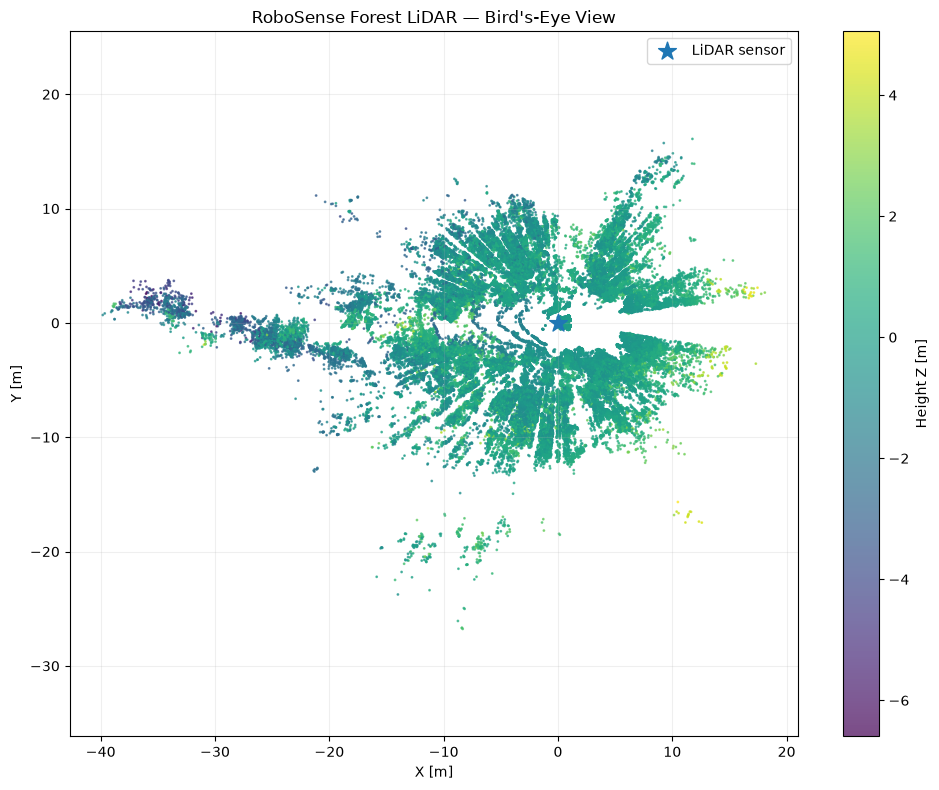

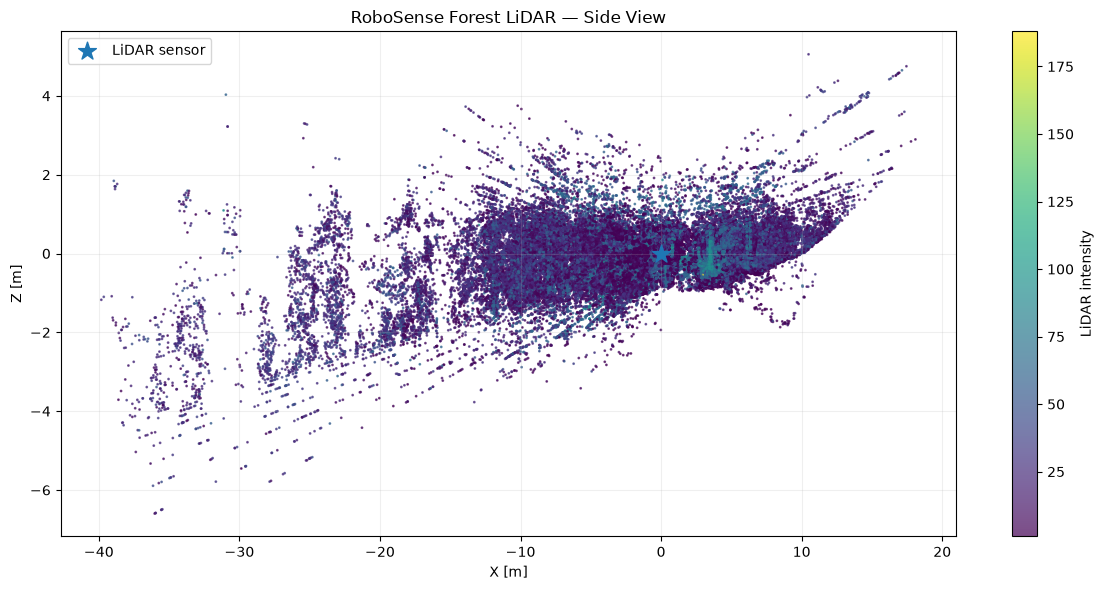


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_robosense_birdseye.png
D:\Autonomous_Forest_Navigation\figures\green_robosense_sideview.png


In [7]:
# Visualize the real RoboSense forest LiDAR scan

# ---------------------------------------------------------
# 1. Keep only valid finite XYZ points
# ---------------------------------------------------------

valid_mask = np.isfinite(xyz).all(axis=1)

xyz_valid = xyz[valid_mask]
intensity_valid = intensity[valid_mask]

print("LIDAR VISUALIZATION")
print("=" * 70)

print(f"Original points : {len(xyz):,}")
print(f"Valid points    : {len(xyz_valid):,}")


# ---------------------------------------------------------
# 2. Compute horizontal range from the LiDAR
# ---------------------------------------------------------

horizontal_range = np.sqrt(
    xyz_valid[:, 0] ** 2 +
    xyz_valid[:, 1] ** 2
)

# Keep a useful visualization region
VIS_RANGE = 45.0

range_mask = (
    horizontal_range <= VIS_RANGE
)

xyz_plot = xyz_valid[range_mask]
intensity_plot = intensity_valid[range_mask]

print(
    f"Points within {VIS_RANGE:.0f} m : "
    f"{len(xyz_plot):,}"
)


# ---------------------------------------------------------
# 3. Downsample only for plotting speed
#    (the actual point cloud remains untouched)
# ---------------------------------------------------------

MAX_PLOT_POINTS = 100_000

if len(xyz_plot) > MAX_PLOT_POINTS:

    plot_indices = np.linspace(
        0,
        len(xyz_plot) - 1,
        MAX_PLOT_POINTS,
        dtype=int
    )

    xyz_display = xyz_plot[plot_indices]
    intensity_display = intensity_plot[plot_indices]

else:

    xyz_display = xyz_plot
    intensity_display = intensity_plot


# ---------------------------------------------------------
# 4. Bird's-eye view
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    xyz_display[:, 0],
    xyz_display[:, 1],
    c=xyz_display[:, 2],
    s=1,
    alpha=0.7
)

ax.scatter(
    0,
    0,
    marker="*",
    s=180,
    label="LiDAR sensor",
    zorder=5
)

ax.set_title(
    "RoboSense Forest LiDAR — Bird's-Eye View"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.2)
ax.legend()

cbar = plt.colorbar(
    scatter,
    ax=ax
)

cbar.set_label("Height Z [m]")

plt.tight_layout()

bev_figure = (
    FIGURES_DIR /
    "green_robosense_birdseye.png"
)

plt.savefig(
    bev_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 5. Side view
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    xyz_display[:, 0],
    xyz_display[:, 2],
    c=intensity_display,
    s=1,
    alpha=0.7
)

ax.scatter(
    0,
    0,
    marker="*",
    s=180,
    label="LiDAR sensor",
    zorder=5
)

ax.set_title(
    "RoboSense Forest LiDAR — Side View"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")

ax.grid(True, alpha=0.2)
ax.legend()

cbar = plt.colorbar(
    scatter,
    ax=ax
)

cbar.set_label("LiDAR intensity")

plt.tight_layout()

side_figure = (
    FIGURES_DIR /
    "green_robosense_sideview.png"
)

plt.savefig(
    side_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nFigures saved:")
print(bev_figure)
print(side_figure)

GROUND / OBSTACLE SEGMENTATION
Points within 35 m : 161,735

SEGMENTATION RESULT
Ground points   : 45,294
Obstacle points : 116,441
Ground fraction : 28.0 %
Obstacle fraction: 72.0 %


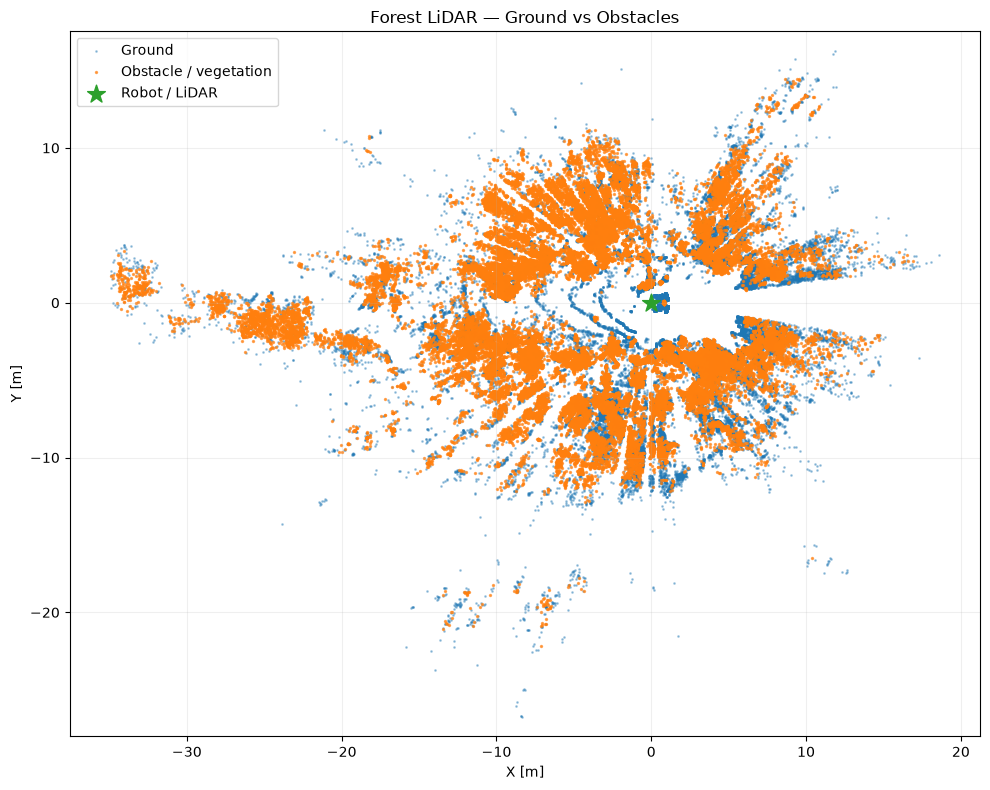

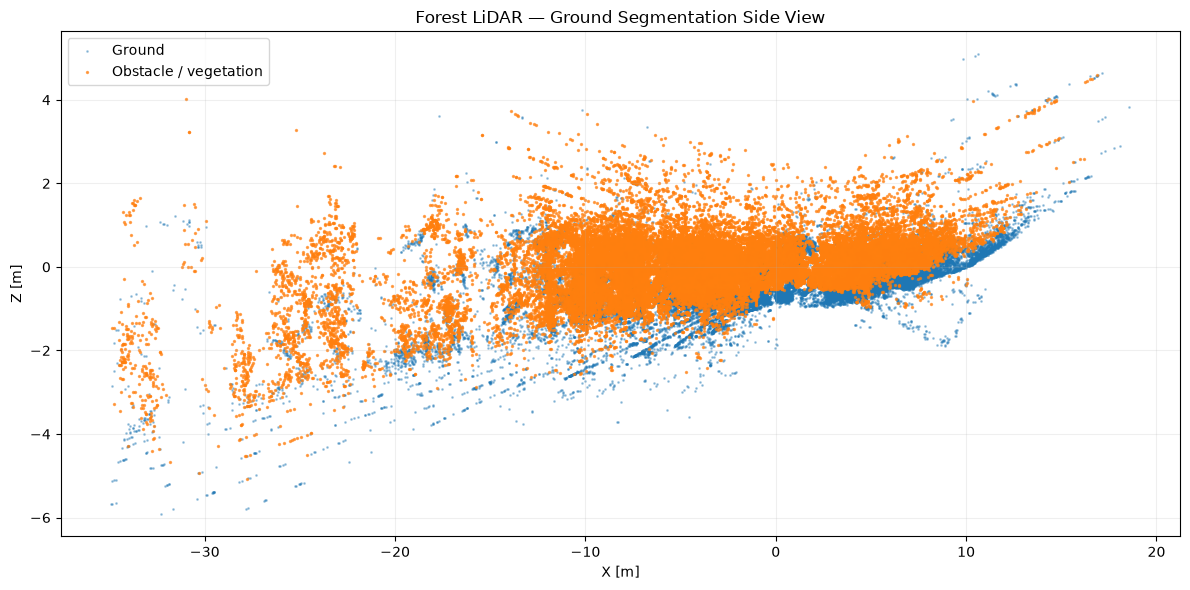


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_lidar_ground_obstacle_bev.png
D:\Autonomous_Forest_Navigation\figures\green_lidar_ground_obstacle_side.png


In [8]:
# Separate likely ground points from obstacle / vegetation points
# using a local grid-based terrain model.

# ---------------------------------------------------------
# 1. Work within a useful local navigation radius
# ---------------------------------------------------------

PROCESS_RANGE = 35.0  # metres

horizontal_range = np.sqrt(
    xyz_valid[:, 0] ** 2 +
    xyz_valid[:, 1] ** 2
)

process_mask = (
    horizontal_range <= PROCESS_RANGE
)

xyz_process = xyz_valid[process_mask]

print("GROUND / OBSTACLE SEGMENTATION")
print("=" * 70)

print(
    f"Points within {PROCESS_RANGE:.0f} m : "
    f"{len(xyz_process):,}"
)


# ---------------------------------------------------------
# 2. Create XY terrain cells
# ---------------------------------------------------------

GRID_SIZE = 0.50  # metres

cell_x = np.floor(
    xyz_process[:, 0] / GRID_SIZE
).astype(int)

cell_y = np.floor(
    xyz_process[:, 1] / GRID_SIZE
).astype(int)

terrain_df = pd.DataFrame({
    "x": xyz_process[:, 0],
    "y": xyz_process[:, 1],
    "z": xyz_process[:, 2],
    "cell_x": cell_x,
    "cell_y": cell_y
})


# ---------------------------------------------------------
# 3. Estimate local ground height
#
# Use the minimum Z in each local XY cell as a first
# approximation of the terrain surface.
# ---------------------------------------------------------

local_ground = (
    terrain_df
    .groupby(
        ["cell_x", "cell_y"]
    )["z"]
    .min()
    .rename("ground_z")
)

terrain_df = terrain_df.join(
    local_ground,
    on=["cell_x", "cell_y"]
)


# ---------------------------------------------------------
# 4. Height above local terrain
# ---------------------------------------------------------

terrain_df["height_above_ground"] = (
    terrain_df["z"] -
    terrain_df["ground_z"]
)


# ---------------------------------------------------------
# 5. Ground classification
# ---------------------------------------------------------

GROUND_THRESHOLD = 0.35  # metres

ground_mask = (
    terrain_df["height_above_ground"]
    <= GROUND_THRESHOLD
).to_numpy()

obstacle_mask = ~ground_mask

ground_points = xyz_process[
    ground_mask
]

obstacle_points = xyz_process[
    obstacle_mask
]


# ---------------------------------------------------------
# 6. Summary
# ---------------------------------------------------------

print("\nSEGMENTATION RESULT")
print("=" * 70)

print(
    f"Ground points   : "
    f"{len(ground_points):,}"
)

print(
    f"Obstacle points : "
    f"{len(obstacle_points):,}"
)

print(
    f"Ground fraction : "
    f"{100 * len(ground_points) / len(xyz_process):.1f} %"
)

print(
    f"Obstacle fraction: "
    f"{100 * len(obstacle_points) / len(xyz_process):.1f} %"
)


# ---------------------------------------------------------
# 7. Bird's-eye segmentation plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

# Downsample only for plotting
GROUND_PLOT_STEP = max(
    1,
    len(ground_points) // 50_000
)

OBSTACLE_PLOT_STEP = max(
    1,
    len(obstacle_points) // 50_000
)

ax.scatter(
    ground_points[
        ::GROUND_PLOT_STEP, 0
    ],
    ground_points[
        ::GROUND_PLOT_STEP, 1
    ],
    s=1,
    alpha=0.35,
    label="Ground"
)

ax.scatter(
    obstacle_points[
        ::OBSTACLE_PLOT_STEP, 0
    ],
    obstacle_points[
        ::OBSTACLE_PLOT_STEP, 1
    ],
    s=2,
    alpha=0.65,
    label="Obstacle / vegetation"
)

ax.scatter(
    0,
    0,
    marker="*",
    s=180,
    label="Robot / LiDAR",
    zorder=5
)

ax.set_title(
    "Forest LiDAR — Ground vs Obstacles"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()

segmentation_bev_figure = (
    FIGURES_DIR /
    "green_lidar_ground_obstacle_bev.png"
)

plt.savefig(
    segmentation_bev_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 8. Side-view segmentation
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    ground_points[
        ::GROUND_PLOT_STEP, 0
    ],
    ground_points[
        ::GROUND_PLOT_STEP, 2
    ],
    s=1,
    alpha=0.35,
    label="Ground"
)

ax.scatter(
    obstacle_points[
        ::OBSTACLE_PLOT_STEP, 0
    ],
    obstacle_points[
        ::OBSTACLE_PLOT_STEP, 2
    ],
    s=2,
    alpha=0.65,
    label="Obstacle / vegetation"
)

ax.set_title(
    "Forest LiDAR — Ground Segmentation Side View"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")

ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()

segmentation_side_figure = (
    FIGURES_DIR /
    "green_lidar_ground_obstacle_side.png"
)

plt.savefig(
    segmentation_side_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nFigures saved:")
print(segmentation_bev_figure)
print(segmentation_side_figure)

REFINED TERRAIN SEGMENTATION
Total points              : 161,735
Likely ground             : 95,845
Navigation obstacles      : 64,210
High vegetation / canopy  : 1,680

Ground fraction           : 59.3 %
Navigation obstacle frac. : 39.7 %


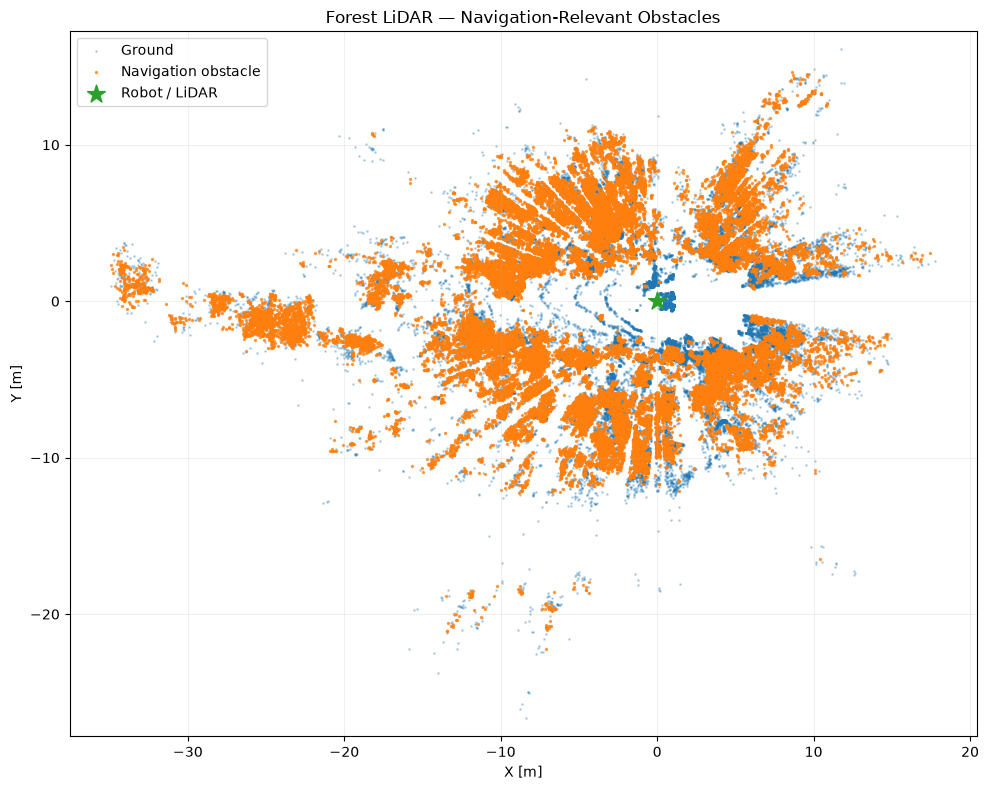

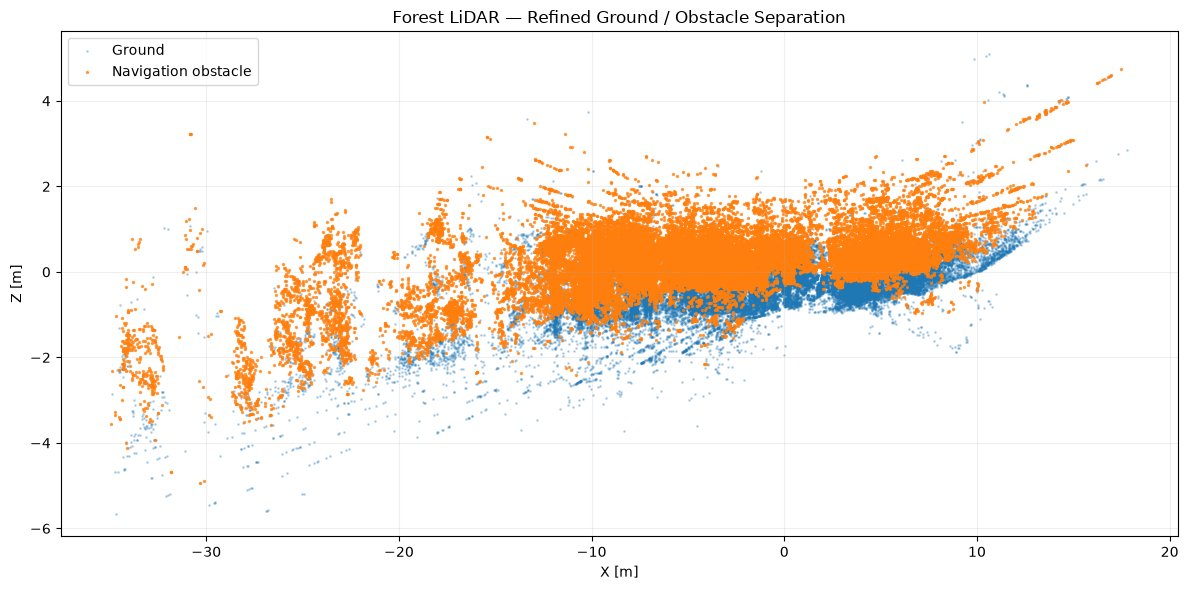


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_lidar_navigation_obstacles_bev.png
D:\Autonomous_Forest_Navigation\figures\green_lidar_navigation_obstacles_side.png


In [9]:
# Refine terrain segmentation and extract navigation-relevant obstacles

# ---------------------------------------------------------
# 1. Rebuild local terrain grid
# ---------------------------------------------------------

GRID_SIZE = 0.50

cell_x = np.floor(
    xyz_process[:, 0] / GRID_SIZE
).astype(int)

cell_y = np.floor(
    xyz_process[:, 1] / GRID_SIZE
).astype(int)

terrain_df = pd.DataFrame({
    "x": xyz_process[:, 0],
    "y": xyz_process[:, 1],
    "z": xyz_process[:, 2],
    "cell_x": cell_x,
    "cell_y": cell_y
})


# ---------------------------------------------------------
# 2. Robust local ground estimate
#
# 10th percentile is less sensitive than the absolute minimum
# ---------------------------------------------------------

local_ground_robust = (
    terrain_df
    .groupby(
        ["cell_x", "cell_y"]
    )["z"]
    .quantile(0.10)
    .rename("ground_z")
)

terrain_df = terrain_df.join(
    local_ground_robust,
    on=["cell_x", "cell_y"]
)


# ---------------------------------------------------------
# 3. Height above local terrain
# ---------------------------------------------------------

terrain_df["height_above_ground"] = (
    terrain_df["z"] -
    terrain_df["ground_z"]
)


# ---------------------------------------------------------
# 4. Ground classification
# ---------------------------------------------------------

GROUND_THRESHOLD = 0.45

ground_mask_refined = (
    terrain_df["height_above_ground"]
    <= GROUND_THRESHOLD
).to_numpy()

ground_points_refined = xyz_process[
    ground_mask_refined
]


# ---------------------------------------------------------
# 5. Navigation-relevant obstacle band
#
# Ignore tiny terrain roughness and very high canopy points.
# We care about objects intersecting the robot body.
# ---------------------------------------------------------

OBSTACLE_MIN_HEIGHT = 0.45
OBSTACLE_MAX_HEIGHT = 2.50

navigation_obstacle_mask = (
    (terrain_df["height_above_ground"] > OBSTACLE_MIN_HEIGHT) &
    (terrain_df["height_above_ground"] <= OBSTACLE_MAX_HEIGHT)
).to_numpy()

navigation_obstacles = xyz_process[
    navigation_obstacle_mask
]


# ---------------------------------------------------------
# 6. High vegetation / canopy
# ---------------------------------------------------------

high_vegetation_mask = (
    terrain_df["height_above_ground"]
    > OBSTACLE_MAX_HEIGHT
).to_numpy()

high_vegetation = xyz_process[
    high_vegetation_mask
]


# ---------------------------------------------------------
# 7. Summary
# ---------------------------------------------------------

print("REFINED TERRAIN SEGMENTATION")
print("=" * 70)

print(
    f"Total points              : "
    f"{len(xyz_process):,}"
)

print(
    f"Likely ground             : "
    f"{len(ground_points_refined):,}"
)

print(
    f"Navigation obstacles      : "
    f"{len(navigation_obstacles):,}"
)

print(
    f"High vegetation / canopy  : "
    f"{len(high_vegetation):,}"
)

print()

print(
    f"Ground fraction           : "
    f"{100 * len(ground_points_refined) / len(xyz_process):.1f} %"
)

print(
    f"Navigation obstacle frac. : "
    f"{100 * len(navigation_obstacles) / len(xyz_process):.1f} %"
)


# ---------------------------------------------------------
# 8. Bird's-eye view
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ground_step = max(
    1,
    len(ground_points_refined) // 45_000
)

obstacle_step = max(
    1,
    len(navigation_obstacles) // 45_000
)

ax.scatter(
    ground_points_refined[::ground_step, 0],
    ground_points_refined[::ground_step, 1],
    s=1,
    alpha=0.25,
    label="Ground"
)

ax.scatter(
    navigation_obstacles[::obstacle_step, 0],
    navigation_obstacles[::obstacle_step, 1],
    s=2,
    alpha=0.70,
    label="Navigation obstacle"
)

ax.scatter(
    0,
    0,
    marker="*",
    s=180,
    zorder=5,
    label="Robot / LiDAR"
)

ax.set_title(
    "Forest LiDAR — Navigation-Relevant Obstacles"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()

refined_bev_figure = (
    FIGURES_DIR /
    "green_lidar_navigation_obstacles_bev.png"
)

plt.savefig(
    refined_bev_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 9. Side view
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    ground_points_refined[::ground_step, 0],
    ground_points_refined[::ground_step, 2],
    s=1,
    alpha=0.25,
    label="Ground"
)

ax.scatter(
    navigation_obstacles[::obstacle_step, 0],
    navigation_obstacles[::obstacle_step, 2],
    s=2,
    alpha=0.70,
    label="Navigation obstacle"
)

ax.set_title(
    "Forest LiDAR — Refined Ground / Obstacle Separation"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")

ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()

refined_side_figure = (
    FIGURES_DIR /
    "green_lidar_navigation_obstacles_side.png"
)

plt.savefig(
    refined_side_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nFigures saved:")
print(refined_bev_figure)
print(refined_side_figure)

In [10]:
# Save processed LiDAR results for the mapping stage

PROCESSED_LIDAR_DIR = (
    OUTPUTS_DIR /
    "processed_lidar"
)

PROCESSED_LIDAR_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PROCESSED_SCAN_FILE = (
    PROCESSED_LIDAR_DIR /
    "green_robosense_sample_processed.npz"
)

np.savez_compressed(
    PROCESSED_SCAN_FILE,

    # Original valid points inside processing range
    xyz=xyz_process,

    # Terrain segmentation
    ground_points=ground_points_refined,

    # Navigation-relevant obstacles
    obstacle_points=navigation_obstacles,

    # Higher vegetation
    high_vegetation=high_vegetation,

    # Scan information
    scan_timestamp_us=np.array(
        [point_time_us.min()],
        dtype=np.uint64
    ),

    grid_size=np.array(
        [GRID_SIZE]
    ),

    ground_threshold=np.array(
        [GROUND_THRESHOLD]
    ),

    obstacle_min_height=np.array(
        [OBSTACLE_MIN_HEIGHT]
    ),

    obstacle_max_height=np.array(
        [OBSTACLE_MAX_HEIGHT]
    )
)

print("PROCESSED LIDAR SAVED")
print("=" * 70)

print("File:")
print(PROCESSED_SCAN_FILE)

print(
    f"\nFile size : "
    f"{PROCESSED_SCAN_FILE.stat().st_size / (1024 ** 2):.3f} MB"
)

print("\nStored arrays:")
print("  xyz")
print("  ground_points")
print("  obstacle_points")
print("  high_vegetation")
print("  scan_timestamp_us")

print("\nParameters:")
print(f"  Grid size           : {GRID_SIZE:.2f} m")
print(f"  Ground threshold    : {GROUND_THRESHOLD:.2f} m")
print(
    f"  Obstacle height     : "
    f"{OBSTACLE_MIN_HEIGHT:.2f} – "
    f"{OBSTACLE_MAX_HEIGHT:.2f} m"
)

PROCESSED LIDAR SAVED
File:
D:\Autonomous_Forest_Navigation\outputs\processed_lidar\green_robosense_sample_processed.npz

File size : 3.360 MB

Stored arrays:
  xyz
  ground_points
  obstacle_points
  high_vegetation
  scan_timestamp_us

Parameters:
  Grid size           : 0.50 m
  Ground threshold    : 0.45 m
  Obstacle height     : 0.45 – 2.50 m
